# NovaMarket — Correlación, causalidad y experimento A/B

## Pregunta central del caso

NovaMarket observa que en los períodos donde aumenta la inversión publicitaria también aumentan las ventas.

La gerencia podría concluir:

> **“Si aumentamos la publicidad, las ventas aumentan gracias a la publicidad.”**

El problema es que durante noviembre y diciembre también aumenta naturalmente la demanda.

Por lo tanto, tenemos tres relaciones posibles:

**Navidad → Publicidad**

**Navidad → Ventas**

**Publicidad → Ventas**

El objetivo del caso es responder:

> **¿Cuánto del aumento observado en ventas está simplemente asociado con la publicidad y cuánto podemos atribuir causalmente a una intervención publicitaria?**

## Distinción clave

No vamos a decir que una parte de las ventas “es correlación”.

La **correlación describe asociación**, no una cantidad de ventas.

Compararemos:

1. Asociación observada sin controlar otras variables.
2. Asociación observada controlando Navidad.
3. Efecto causal estimado mediante un experimento A/B.

La comparación final nos permitirá identificar cuánto estaba sobreestimando el análisis histórico el verdadero impacto de la publicidad.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
# Activate dark mode styling for the plots
plt.style.use('dark_background')

In [4]:
from google.colab import files
import os

print("Please select the files from your 'dataset' folder to upload.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# After uploading, you might want to move these files into a 'dataset' directory
# This assumes you want to recreate the 'dataset' subdirectory in Colab

# Create the 'dataset' directory if it doesn't exist
dataset_dir = 'dataset'
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)
    print(f"Created directory: {dataset_dir}")

# Move uploaded files into the 'dataset' directory
for filename in uploaded.keys():
    os.rename(filename, os.path.join(dataset_dir, filename))
    print(f"Moved '{filename}' to '{os.path.join(dataset_dir, filename)}'")

print("Upload and organization complete. You can now re-run the cell to read your data.")

Please select the files from your 'dataset' folder to upload.


Saving Craft Beers.xlsx to Craft Beers.xlsx
Saving dataset_causalidad_salud.csv to dataset_causalidad_salud.csv
Saving dataset_correlacion_espuria.csv to dataset_correlacion_espuria.csv
Saving DatasetPosturePersonality.csv to DatasetPosturePersonality.csv
Saving Howell1.csv to Howell1.csv
Saving NovaMarket_Dataset_Historico.xlsx to NovaMarket_Dataset_Historico.xlsx
User uploaded file "Craft Beers.xlsx" with length 147036 bytes
User uploaded file "dataset_causalidad_salud.csv" with length 4140 bytes
User uploaded file "dataset_correlacion_espuria.csv" with length 6601 bytes
User uploaded file "DatasetPosturePersonality.csv" with length 82812 bytes
User uploaded file "Howell1.csv" with length 12109 bytes
User uploaded file "NovaMarket_Dataset_Historico.xlsx" with length 772736 bytes
Created directory: dataset
Moved 'Craft Beers.xlsx' to 'dataset/Craft Beers.xlsx'
Moved 'dataset_causalidad_salud.csv' to 'dataset/dataset_causalidad_salud.csv'
Moved 'dataset_correlacion_espuria.csv' to 'dat

## Cargar datos desde el subdirectorio 'dataset'

Para cargar archivos desde un subdirectorio llamado `dataset` (asumiendo que está en el mismo nivel que tu notebook), puedes construir la ruta relativa. A continuación, se muestra un ejemplo de cómo leer un archivo CSV llamado `your_data.csv`.

In [3]:
import pandas as pd
import os

# Construct the path to the dataset directory
dataset_path = os.path.join(os.getcwd(), 'dataset')

# List files in the dataset directory (optional, for verification)
print(f"Files in '{dataset_path}': {os.listdir(dataset_path) if os.path.exists(dataset_path) else 'Directory not found.'}")

# Example: Read a CSV file from the dataset directory
# Replace 'your_data.csv' with the actual name of your file
try:
    df_from_dataset = pd.read_csv(os.path.join(dataset_path, 'your_data.csv'))
    print("Successfully loaded 'your_data.csv':")
    display(df_from_dataset.head())
except FileNotFoundError:
    print(f"Error: 'your_data.csv' not found in '{dataset_path}'. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Files in '/content/dataset': Directory not found.
Error: 'your_data.csv' not found in '/content/dataset'. Please ensure the file exists.


# Paso 1 — Cargar el dataset histórico

## Pregunta

**¿Qué información histórica tenemos disponible para investigar el problema?**

Este notebook utiliza directamente el archivo:

`NovaMarket_Dataset_Historico.xlsx`

No vamos a regenerar el dataset histórico.


In [5]:
rutas_posibles = [
    Path("NovaMarket_Dataset_Historico.xlsx"),
    Path("dataset/NovaMarket_Dataset_Historico.xlsx"),
    Path("/mnt/data/NovaMarket_Dataset_Historico.xlsx")
]

archivo = next(
    (ruta for ruta in rutas_posibles if ruta.exists()),
    None
)

if archivo is None:
    raise FileNotFoundError(
        "Suba NovaMarket_Dataset_Historico.xlsx al entorno antes de continuar."
    )

datos = pd.read_excel(
    archivo,
    sheet_name="Datos_Historicos"
)

datos.head()


,id_cliente,fecha,anio,mes_num,mes,temporada,es_navidad,segmento_cliente,canal,region,inversion_publicidad,exposicion_publicidad,visitas_web,descuento_pct,precio_promedio,prob_compra,compra,unidades_vendidas,ventas
0,C00001,2025-02-02,2025,2,Febrero,Regular,0,Recurrente,Buscadores,Pacífico,26.2600,1,1,4.7400,144.7000,0.2187,1,1,137.8400
1,C00002,2025-10-10,2025,10,Octubre,Regular,0,Recurrente,Buscadores,Caribe,20.9500,1,0,4.6000,139.5300,0.1457,0,0,0.0000
2,C00003,2025-08-27,2025,8,Agosto,Regular,0,Premium,Redes Sociales,Central,29.7800,5,9,8.0200,202.5900,0.5411,1,1,186.3500
3,C00004,2025-06-10,2025,6,Junio,Regular,0,Nuevo,Orgánico,Central,17.8600,1,2,4.0300,165.6000,0.1291,0,0,0.0000
4,C00005,2025-06-08,2025,6,Junio,Regular,0,Recurrente,Redes Sociales,Norte,29.0200,4,6,0.5200,197.2300,0.3576,1,3,588.6200


## Validación rápida del dataset


In [6]:
print("Filas:", datos.shape[0])
print("Columnas:", datos.shape[1])
print("Nulos:", datos.isnull().sum().sum())
print("Duplicados:", datos.duplicated().sum())
print("Fecha mínima:", datos["fecha"].min())
print("Fecha máxima:", datos["fecha"].max())


Filas: 8000
Columnas: 19
Nulos: 0
Duplicados: 0
Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-12-31 00:00:00


### Conclusión

Tenemos 8.000 observaciones históricas correspondientes al año 2025.

Las variables principales serán:

- `inversion_publicidad`
- `ventas`

y una posible variable de confusión:

- `es_navidad`


# Paso 2 — ¿Qué ocurrió históricamente con publicidad y ventas?

## Pregunta

**¿Publicidad y ventas aumentan en los mismos períodos del año?**

Primero observaremos ambos comportamientos por mes.


In [7]:
resumen_mes = (
    datos
    .groupby(["mes_num", "mes"])
    .agg(
        publicidad_promedio=("inversion_publicidad", "mean"),
        ventas_promedio=("ventas", "mean")
    )
    .reset_index()
    .sort_values("mes_num")
)

resumen_mes.round(2)


,mes_num,mes,publicidad_promedio,ventas_promedio
0,1,Enero,21.9800,58.4200
1,2,Febrero,20.9500,60.6400
2,3,Marzo,21.1600,58.2300
3,4,Abril,21.4000,51.6300
4,5,Mayo,21.2200,62.9200
5,6,Junio,21.3200,63.0200
6,7,Julio,21.6000,51.8200
7,8,Agosto,21.2800,59.5200
8,9,Septiembre,20.9800,59.4400
9,10,Octubre,21.3400,72.4500


## Ventas promedio por mes


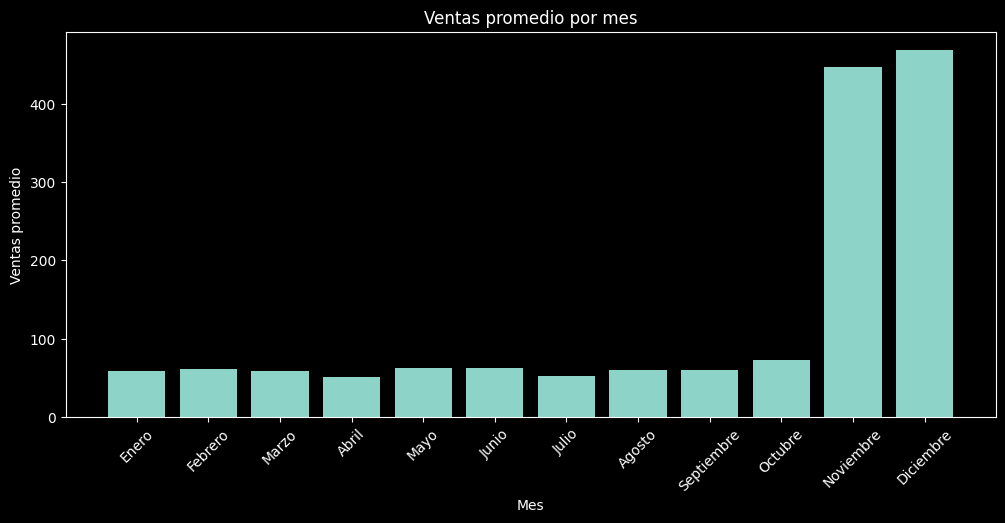

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(
    resumen_mes["mes"],
    resumen_mes["ventas_promedio"]
)

plt.title("Ventas promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)

plt.show()


## Inversión publicitaria promedio por mes


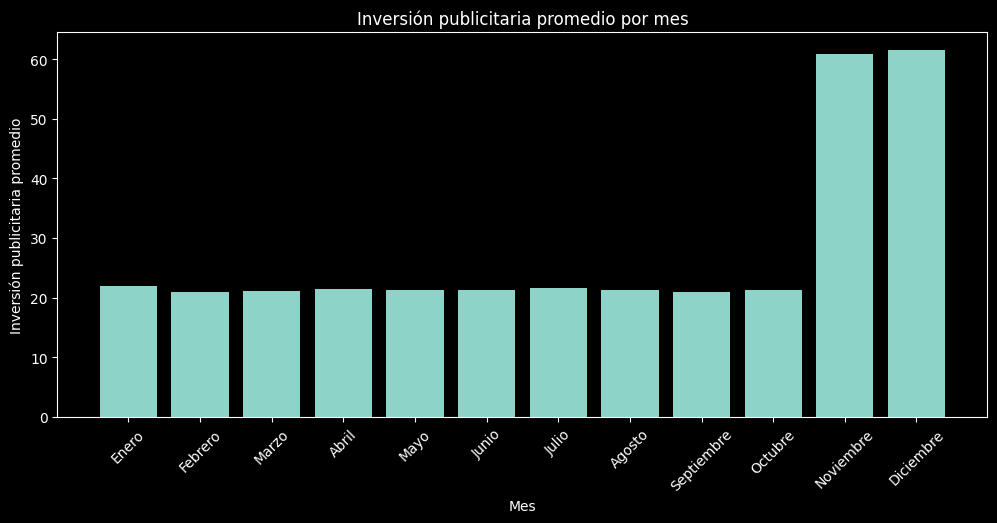

In [9]:
plt.figure(figsize=(12, 5))

plt.bar(
    resumen_mes["mes"],
    resumen_mes["publicidad_promedio"]
)

plt.title("Inversión publicitaria promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Inversión publicitaria promedio")
plt.xticks(rotation=45)

plt.show()


### Lo que observamos

Noviembre y diciembre presentan simultáneamente:

**Publicidad ↑**

y

**Ventas ↑**

Si termináramos el análisis aquí, podríamos atribuir todo el crecimiento de ventas a la publicidad.

Ese sería precisamente el error que queremos investigar.


# Paso 3 — Medir la correlación inicial

## Pregunta

**¿Qué tan fuerte es la asociación entre inversión publicitaria y ventas cuando mezclamos todos los meses?**

La correlación de Pearson mide cuánto se mueven juntas dos variables.

Pero debemos recordar:

> **Una correlación alta no demuestra que una variable esté causando a la otra.**


In [10]:
correlacion_global = datos[
    "inversion_publicidad"
].corr(
    datos["ventas"]
)

print(
    f"Correlación publicidad - ventas: {correlacion_global:.3f}"
)


Correlación publicidad - ventas: 0.639


## Visualizar la relación


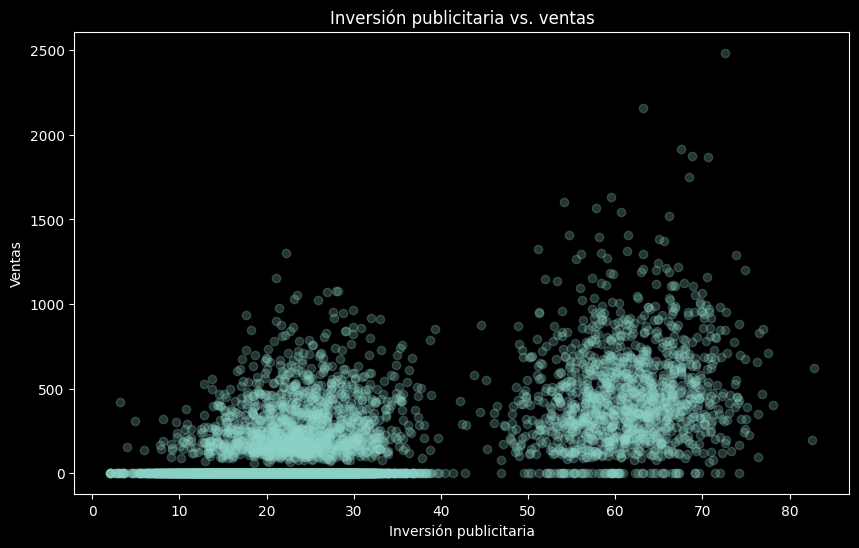

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    datos["inversion_publicidad"],
    datos["ventas"],
    alpha=0.25
)

plt.title("Inversión publicitaria vs. ventas")
plt.xlabel("Inversión publicitaria")
plt.ylabel("Ventas")

plt.show()


### Interpretación

La correlación global es positiva y relativamente fuerte.

Los datos históricos dicen:

> **Cuando la publicidad es mayor, las ventas también tienden a ser mayores.**

Pero todavía no sabemos si:

**Publicidad → Ventas**

o si una tercera variable está haciendo que ambas aumenten simultáneamente.


# Paso 4 — Investigar la temporada navideña

## Pregunta

**¿Navidad está asociada tanto con mayor publicidad como con mayores ventas?**

Si la respuesta es sí, Navidad puede actuar como una variable de confusión.


In [12]:
comparacion_temporada = (
    datos
    .groupby("temporada")
    .agg(
        observaciones=("id_cliente", "count"),
        publicidad_promedio=("inversion_publicidad", "mean"),
        ventas_promedio=("ventas", "mean"),
        conversion=("compra", "mean"),
        visitas_promedio=("visitas_web", "mean")
    )
)

comparacion_temporada["conversion"] *= 100

comparacion_temporada.round(2)


,observaciones,publicidad_promedio,ventas_promedio,conversion,visitas_promedio
temporada,,,,,
Navideña,1305,61.2400,458.4600,94.7900,8.2200
Regular,6695,21.3300,59.7500,20.4200,3.0200


### El problema empieza a quedar claro

Durante Navidad ocurren simultáneamente:

**Navidad → Publicidad ↑**

y:

**Navidad → Ventas ↑**

Por lo tanto, una parte de la relación publicidad–ventas podría estar siendo producida por la temporada y no exclusivamente por la publicidad.


# Paso 5 — ¿La correlación se mantiene dentro de cada temporada?

## Pregunta

**Si comparamos observaciones dentro de períodos similares, la relación publicidad–ventas sigue siendo igual de fuerte?**

Calcularemos tres correlaciones:

1. Todos los datos.
2. Solamente temporada regular.
3. Solamente temporada navideña.


In [13]:
corr_global = datos[
    "inversion_publicidad"
].corr(
    datos["ventas"]
)

corr_regular = datos.loc[
    datos["es_navidad"] == 0,
    "inversion_publicidad"
].corr(
    datos.loc[
        datos["es_navidad"] == 0,
        "ventas"
    ]
)

corr_navidad = datos.loc[
    datos["es_navidad"] == 1,
    "inversion_publicidad"
].corr(
    datos.loc[
        datos["es_navidad"] == 1,
        "ventas"
    ]
)

comparacion_correlaciones = pd.DataFrame({
    "Escenario": [
        "Todos los datos",
        "Temporada regular",
        "Temporada navideña"
    ],
    "Correlación": [
        corr_global,
        corr_regular,
        corr_navidad
    ]
})

comparacion_correlaciones.round(3)


,Escenario,Correlación
0,Todos los datos,0.6390
1,Temporada regular,0.2030
2,Temporada navideña,0.1590


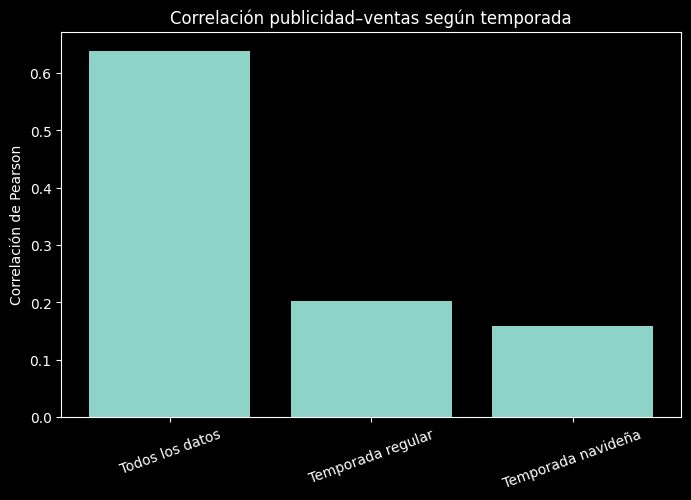

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_correlaciones["Escenario"],
    comparacion_correlaciones["Correlación"]
)

plt.title("Correlación publicidad–ventas según temporada")
plt.ylabel("Correlación de Pearson")
plt.xticks(rotation=20)

plt.show()


### Interpretación

La correlación es mucho mayor cuando mezclamos todos los meses que cuando analizamos cada temporada por separado.

Esto indica que la estacionalidad está inflando la asociación global.

Pero todavía queda una relación positiva dentro de las temporadas.

Por lo tanto:

> **No podemos concluir que toda la relación sea falsa.**

La publicidad podría tener un efecto real; simplemente necesitamos separar mejor ese efecto de la temporada.


# Paso 6 — Cuantificar cuánto sobreestima el análisis histórico

## Pregunta

**¿Cuánto cambia la relación estimada entre publicidad y ventas cuando controlamos Navidad?**

La correlación `r` no está expresada en dólares, por lo que no podemos decir:

> “0.639 significa que 63.9% de las ventas provienen de publicidad.”

Para cuantificar la relación en unidades interpretables utilizaremos una regresión sencilla.

### Modelo ingenuo

`Ventas = β0 + β1 × Publicidad`

### Modelo controlando Navidad

`Ventas = β0 + β1 × Publicidad + β2 × Navidad`

El coeficiente de publicidad nos indica cuánto cambian las ventas, en promedio, por cada $1 adicional de inversión publicitaria.

------------------------------
Las `β` representan el efecto o impacto que tiene cada variable independiente sobre la variable que quieres predecir (en este caso, las Ventas)

En econometría y estadística, las $\beta$ (betas) representan el efecto o impacto que tiene cada variable independiente sobre la variable que quieres predecir (en este caso, las Ventas).
Aquí tienes el significado exacto de $\beta_1$ y $\beta_2$ en cada uno de tus modelos:
## 1. En el Modelo Ingenuo
Ventas = β0 + β1 × Publicidad

* $\beta_1$ es el efecto bruto de la publicidad: Te dice cuánto aumentan las ventas por cada dólar (o unidad) adicional que inviertes en publicidad.
* El problema de este modelo: Como es "ingenuo", este coeficiente $\beta_1$ podría estar inflado. Si sueles invertir mucho en publicidad durante diciembre, $\beta_1$ se va a adjudicar el éxito de las compras navideñas, haciendo parecer que la publicidad es más poderosa de lo que realmente es (un ejemplo de la correlación espuria que vimos antes).

------------------------------
## 2. En el Modelo controlando Navidad
Ventas = β0 + β1 × Publicidad + β2 × Navidad
Al agregar la variable Navidad (que suele ser una variable "dummy": 1 si es época navideña, 0 si no lo es), el significado de las betas cambia por completo:

* $\beta_1$ es el efecto neto de la publicidad (controlado): Te dice cuánto aumentan las ventas por cada dólar invertido en publicidad, pero aislando por completo el efecto de las fiestas. Es el impacto real y puro de tus anuncios. Normalmente, este nuevo $\beta_1$ será menor que el del modelo ingenuo.
* $\beta_2$ es el efecto directo de la Navidad: Te dice cuántas ventas extra genera el simple hecho de estar en temporada navideña, manteniendo la inversión en publicidad constante. Es el impulso natural que tiene el mercado en esa fecha debido al comportamiento de los consumidores.

------------------------------
## En resumen: ¿Cuál es la diferencia?

| Coeficiente | En el Modelo Ingenuo | En el Modelo Controlando Navidad |
|---|---|---|
| $\beta_1$ (Publicidad) | Impacto de la publicidad mezclado con el efecto de las fiestas. | Impacto real y aislado de la publicidad. |
| $\beta_2$ (Navidad) | No existe (su efecto está oculto dentro de $\beta_1$). | El aumento de ventas exclusivo por la temporada navideña. |


In [15]:
modelo_ingenuo = smf.ols(
    "ventas ~ inversion_publicidad",
    data=datos
).fit()

modelo_ajustado = smf.ols(
    "ventas ~ inversion_publicidad + es_navidad",
    data=datos
).fit()

beta_ingenuo = modelo_ingenuo.params[
    "inversion_publicidad"
]

beta_ajustado = modelo_ajustado.params[
    "inversion_publicidad"
]

reduccion = beta_ingenuo - beta_ajustado

reduccion_pct = (
    reduccion / beta_ingenuo
) * 100

comparacion_modelos = pd.DataFrame({
    "Estimación": [
        "Asociación sin controlar Navidad",
        "Asociación controlando Navidad"
    ],
    "Ventas por $1 adicional de publicidad": [
        beta_ingenuo,
        beta_ajustado
    ]
})

comparacion_modelos.round(2)


,Estimación,Ventas por $1 adicional de publicidad
0,Asociación sin controlar Navidad,9.2600
1,Asociación controlando Navidad,5.1800


In [16]:
print(
    f"Sin controlar Navidad: "
    f"${beta_ingenuo:.2f} de ventas por cada $1 de publicidad"
)

print(
    f"Controlando Navidad: "
    f"${beta_ajustado:.2f} de ventas por cada $1 de publicidad"
)

print(
    f"Reducción de la asociación estimada: "
    f"${reduccion:.2f}"
)

print(
    f"Reducción porcentual: "
    f"{reduccion_pct:.1f}%"
)


Sin controlar Navidad: $9.26 de ventas por cada $1 de publicidad
Controlando Navidad: $5.18 de ventas por cada $1 de publicidad
Reducción de la asociación estimada: $4.08
Reducción porcentual: 44.0%


### Qué significa este resultado

El modelo ingenuo atribuye a publicidad una relación mucho mayor.

Cuando incorporamos Navidad, el coeficiente de publicidad disminuye considerablemente.

Eso nos dice que:

> **El análisis histórico estaba atribuyendo a publicidad parte de un crecimiento que también estaba asociado con la temporada navideña.**

Sin embargo, el coeficiente ajustado sigue siendo un resultado **observacional**.

Todavía no debemos llamarlo efecto causal.


# Paso 7 — ¿Qué puede y qué no puede responder el análisis histórico?

Hasta ahora sabemos:

### Evidencia 1

Publicidad y ventas están correlacionadas.

### Evidencia 2

Navidad aumenta publicidad y ventas simultáneamente.

### Evidencia 3

Cuando controlamos Navidad, la asociación publicidad–ventas disminuye.

Pero todavía existe una pregunta que los datos históricos no pueden resolver completamente:

> **¿Qué habría ocurrido con clientes equivalentes si unos recibieran publicidad adicional y otros no?**

Ese es el problema del **contrafactual**.

Por eso necesitamos un experimento A/B.


# Paso 8 — Diseñar el experimento A/B

## Pregunta

**¿Cómo podemos estimar el efecto causal de una campaña publicitaria?**

Utilizaremos los mismos clientes del dataset histórico como base del experimento.

No estamos regenerando el dataset histórico.

Solamente simularemos una nueva intervención experimental porque el archivo original no contiene una campaña A/B real.

Los clientes se asignarán aleatoriamente:

### Control

No recibe publicidad adicional.

### Tratamiento

Recibe una campaña adicional.

La campaña tendrá un costo publicitario adicional de:

**$2.50 por cliente tratado.**


In [17]:
rng_ab = np.random.default_rng(2064)

experimento = datos[
    [
        "id_cliente",
        "segmento_cliente",
        "region",
        "ventas",
        "compra",
        "precio_promedio"
    ]
].copy()

experimento = experimento.rename(
    columns={
        "ventas": "ventas_base",
        "compra": "compra_base"
    }
)

experimento["grupo"] = rng_ab.choice(
    ["Control", "Tratamiento"],
    size=len(experimento),
    p=[0.50, 0.50]
)

experimento["tratamiento"] = (
    experimento["grupo"] == "Tratamiento"
).astype(int)

experimento.head()


,id_cliente,segmento_cliente,region,ventas_base,compra_base,precio_promedio,grupo,tratamiento
0,C00001,Recurrente,Pacífico,137.8400,1,144.7000,Tratamiento,1
1,C00002,Recurrente,Caribe,0.0000,0,139.5300,Tratamiento,1
2,C00003,Premium,Central,186.3500,1,202.5900,Control,0
3,C00004,Nuevo,Central,0.0000,0,165.6000,Tratamiento,1
4,C00005,Recurrente,Norte,588.6200,1,197.2300,Control,0


## Simular el resultado de la campaña

Para fines didácticos supondremos que la campaña puede producir dos efectos:

1. Convertir una pequeña proporción adicional de clientes que originalmente no compraban.
2. Generar una compra adicional pequeña en algunos clientes que ya compraban.

En un experimento real estos resultados no se simularían: simplemente esperaríamos y mediríamos lo ocurrido.


In [18]:
ventas_compradores = datos.loc[
    datos["ventas"] > 0,
    "ventas"
].to_numpy()

conversion_adicional = (
    (experimento["compra_base"] == 0)
    &
    (rng_ab.random(len(experimento)) < 0.05)
).astype(int)

ticket_incremental = np.where(
    conversion_adicional == 1,
    rng_ab.choice(
        ventas_compradores,
        size=len(experimento),
        replace=True
    ),
    0
)

upsell = (
    (experimento["compra_base"] == 1)
    &
    (rng_ab.random(len(experimento)) < 0.08)
).astype(int)

venta_upsell = np.where(
    upsell == 1,
    rng_ab.uniform(
        40,
        120,
        size=len(experimento)
    ),
    0
)

experimento["ventas_con_campana"] = (
    experimento["ventas_base"]
    + ticket_incremental
    + venta_upsell
)

experimento["compra_con_campana"] = (
    experimento["ventas_con_campana"] > 0
).astype(int)

experimento["ventas_observadas"] = np.where(
    experimento["tratamiento"] == 1,
    experimento["ventas_con_campana"],
    experimento["ventas_base"]
)

experimento["compra_observada"] = np.where(
    experimento["tratamiento"] == 1,
    experimento["compra_con_campana"],
    experimento["compra_base"]
)

experimento.head()


,id_cliente,segmento_cliente,region,ventas_base,compra_base,precio_promedio,grupo,tratamiento,ventas_con_campana,compra_con_campana,ventas_observadas,compra_observada
0,C00001,Recurrente,Pacífico,137.8400,1,144.7000,Tratamiento,1,137.8400,1,137.8400,1
1,C00002,Recurrente,Caribe,0.0000,0,139.5300,Tratamiento,1,0.0000,0,0.0000,0
2,C00003,Premium,Central,186.3500,1,202.5900,Control,0,186.3500,1,186.3500,1
3,C00004,Nuevo,Central,0.0000,0,165.6000,Tratamiento,1,0.0000,0,0.0000,0
4,C00005,Recurrente,Norte,588.6200,1,197.2300,Control,0,588.6200,1,588.6200,1


# Paso 9 — Validar la aleatorización

## Pregunta

**¿Los grupos ya eran parecidos antes de aplicar la campaña?**

Si el tratamiento fue asignado aleatoriamente, esperamos que Control y Tratamiento tengan características iniciales aproximadamente similares.


In [19]:
balance = (
    experimento
    .groupby("grupo")
    .agg(
        clientes=("id_cliente", "count"),
        ventas_base_promedio=("ventas_base", "mean"),
        conversion_base=("compra_base", "mean"),
        precio_promedio=("precio_promedio", "mean")
    )
)

balance["conversion_base"] *= 100

balance.round(2)


,clientes,ventas_base_promedio,conversion_base,precio_promedio
grupo,,,,
Control,4021,124.8400,32.3100,173.5000
Tratamiento,3979,124.7500,32.8000,173.9600


## Distribución de segmentos


In [20]:
pd.crosstab(
    experimento["segmento_cliente"],
    experimento["grupo"],
    normalize="columns"
).mul(100).round(2)


grupo,Control,Tratamiento
segmento_cliente,,
Nuevo,35.2600,35.1800
Premium,18.9000,19.6500
Recurrente,45.8300,45.1600


### Conclusión

Antes de la campaña, Control y Tratamiento presentan valores muy similares.

Por eso, después de la intervención, una diferencia sistemática en ventas puede atribuirse con mucha más confianza al tratamiento.


# Paso 10 — Estimar el efecto causal de la publicidad

## Pregunta

**¿Cuánto más vendió el grupo que recibió la campaña?**

La métrica principal será:

`ATE = Venta promedio Tratamiento - Venta promedio Control`

Debido a la asignación aleatoria, esta diferencia puede interpretarse como una estimación del efecto causal promedio del tratamiento.


In [21]:
resultado_ab = (
    experimento
    .groupby("grupo")
    .agg(
        clientes=("id_cliente", "count"),
        venta_promedio=("ventas_observadas", "mean"),
        venta_total=("ventas_observadas", "sum"),
        conversion=("compra_observada", "mean")
    )
)

resultado_ab["conversion"] *= 100

resultado_ab.round(2)


,clientes,venta_promedio,venta_total,conversion
grupo,,,,
Control,4021,124.8400,"501,961.6800",32.3100
Tratamiento,3979,138.0200,"549,179.7800",35.6600


In [22]:
venta_control = resultado_ab.loc[
    "Control",
    "venta_promedio"
]

venta_tratamiento = resultado_ab.loc[
    "Tratamiento",
    "venta_promedio"
]

efecto_causal_ventas = (
    venta_tratamiento
    - venta_control
)

print(
    f"Venta promedio Control: "
    f"${venta_control:.2f}"
)

print(
    f"Venta promedio Tratamiento: "
    f"${venta_tratamiento:.2f}"
)

print(
    f"Efecto causal estimado por cliente: "
    f"${efecto_causal_ventas:.2f}"
)


Venta promedio Control: $124.84
Venta promedio Tratamiento: $138.02
Efecto causal estimado por cliente: $13.18


### Interpretación

Esta diferencia ya no proviene simplemente de observar qué clientes recibieron más publicidad históricamente.

La publicidad fue asignada aleatoriamente.

Por eso la comparación Control–Tratamiento nos ofrece una estimación mucho más fuerte del impacto causal de la campaña.


# Paso 11 — ¿La diferencia del A/B podría ser producto del azar?

## Pregunta

**¿Tenemos suficiente evidencia para considerar que la diferencia observada es real y no solamente variabilidad aleatoria?**

Utilizaremos una prueba t de Welch para comparar la venta promedio por cliente entre ambos grupos.

### Hipótesis

**H0:** venta promedio Tratamiento = venta promedio Control

**H1:** venta promedio Tratamiento ≠ venta promedio Control


In [23]:
ventas_control = experimento.loc[
    experimento["grupo"] == "Control",
    "ventas_observadas"
]

ventas_tratamiento = experimento.loc[
    experimento["grupo"] == "Tratamiento",
    "ventas_observadas"
]

t_stat, p_value = stats.ttest_ind(
    ventas_tratamiento,
    ventas_control,
    equal_var=False
)

print(f"Estadístico t: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(
        "Resultado: existe evidencia estadística "
        "de una diferencia entre los grupos."
    )
else:
    print(
        "Resultado: no existe evidencia estadística "
        "suficiente de una diferencia."
    )


Estadístico t: 2.4955
p-value: 0.012599
Resultado: existe evidencia estadística de una diferencia entre los grupos.


## Intervalo de confianza del efecto causal


In [24]:
var_t = ventas_tratamiento.var(ddof=1)
var_c = ventas_control.var(ddof=1)

n_t = len(ventas_tratamiento)
n_c = len(ventas_control)

error_estandar = np.sqrt(
    var_t / n_t
    +
    var_c / n_c
)

grados_libertad = (
    (var_t / n_t + var_c / n_c) ** 2
    /
    (
        ((var_t / n_t) ** 2 / (n_t - 1))
        +
        ((var_c / n_c) ** 2 / (n_c - 1))
    )
)

critico = stats.t.ppf(
    0.975,
    grados_libertad
)

ic_inferior = (
    efecto_causal_ventas
    - critico * error_estandar
)

ic_superior = (
    efecto_causal_ventas
    + critico * error_estandar
)

print(
    f"Efecto causal estimado: "
    f"${efecto_causal_ventas:.2f}"
)

print(
    f"IC 95%: "
    f"[${ic_inferior:.2f}, ${ic_superior:.2f}]"
)


Efecto causal estimado: $13.18
IC 95%: [$2.83, $23.54]


### Conclusión

El experimento no solamente nos dice que Tratamiento vendió más.

También cuantifica:

- cuánto más vendió;
- qué incertidumbre tiene esa estimación;
- y si la diferencia es consistente con un verdadero efecto del tratamiento.


# Paso 12 — Comparar asociación observada vs. efecto causal

## Pregunta final

**¿Cuánto parecía impactar la publicidad según los datos históricos y cuánto estimamos que realmente causa mediante el A/B?**

Para poder comparar resultados en unidades similares utilizaremos:

### Asociación histórica sin controlar Navidad

Ventas adicionales asociadas con cada $1 adicional de publicidad.

### Asociación histórica controlando Navidad

Ventas adicionales asociadas con cada $1 de publicidad después de controlar la temporada.

### Efecto causal A/B

La campaña cuesta $2.50 adicionales por cada cliente tratado.

Por lo tanto:

`Efecto causal por dólar = Venta adicional causal por cliente / 2.50`


In [25]:
costo_publicidad_adicional = 2.50

efecto_causal_por_dolar = (
    efecto_causal_ventas
    / costo_publicidad_adicional
)

brecha_observacional_causal = (
    beta_ingenuo
    - efecto_causal_por_dolar
)

brecha_pct = (
    brecha_observacional_causal
    / beta_ingenuo
) * 100

resumen_final = pd.DataFrame({
    "Estimación": [
        "Asociación histórica sin controlar Navidad",
        "Asociación histórica controlando Navidad",
        "Efecto causal estimado por A/B"
    ],
    "Ventas por cada $1 adicional de publicidad": [
        beta_ingenuo,
        beta_ajustado,
        efecto_causal_por_dolar
    ]
})

resumen_final.round(2)


,Estimación,Ventas por cada $1 adicional de publicidad
0,Asociación histórica sin controlar Navidad,9.2600
1,Asociación histórica controlando Navidad,5.1800
2,Efecto causal estimado por A/B,5.2700


In [26]:
print(
    f"Asociación histórica ingenua: "
    f"${beta_ingenuo:.2f} por $1"
)

print(
    f"Asociación histórica controlando Navidad: "
    f"${beta_ajustado:.2f} por $1"
)

print(
    f"Efecto causal estimado por A/B: "
    f"${efecto_causal_por_dolar:.2f} por $1"
)

print(
    f"Brecha entre asociación inicial y efecto causal: "
    f"${brecha_observacional_causal:.2f} por $1"
)

print(
    f"Sobreestimación aproximada del análisis ingenuo: "
    f"{brecha_pct:.1f}%"
)


Asociación histórica ingenua: $9.26 por $1
Asociación histórica controlando Navidad: $5.18 por $1
Efecto causal estimado por A/B: $5.27 por $1
Brecha entre asociación inicial y efecto causal: $3.99 por $1
Sobreestimación aproximada del análisis ingenuo: 43.1%


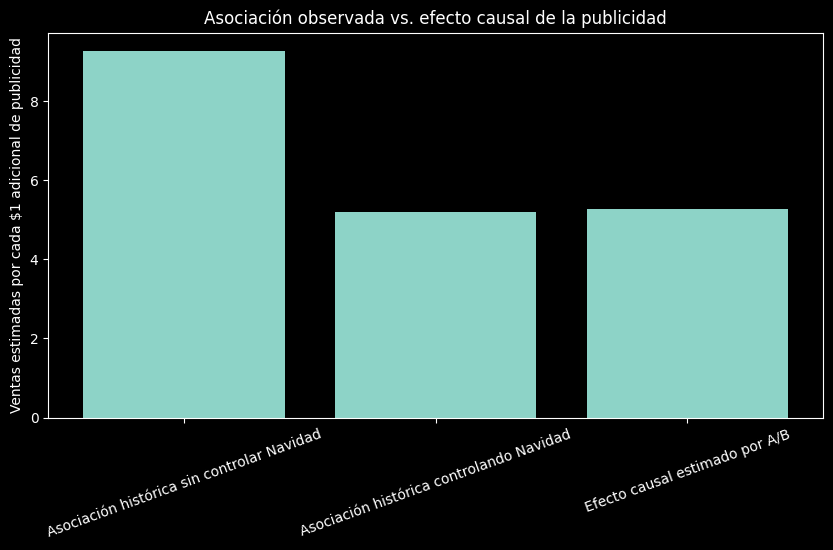

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    resumen_final["Estimación"],
    resumen_final[
        "Ventas por cada $1 adicional de publicidad"
    ]
)

plt.title(
    "Asociación observada vs. efecto causal de la publicidad"
)

plt.ylabel(
    "Ventas estimadas por cada $1 adicional de publicidad"
)

plt.xticks(rotation=20)

plt.show()


# Conclusión final del caso

El caso separa tres conceptos que suelen confundirse.

## 1. Correlación

La publicidad y las ventas muestran una correlación positiva cercana a **0.64**.

Esto significa que se mueven juntas.

No significa que 64% de las ventas sean causadas por publicidad.

## 2. Asociación observacional

Si ignoramos Navidad, el análisis histórico estima aproximadamente:

**$9.26 de ventas adicionales por cada $1 de publicidad.**

Cuando controlamos Navidad, la asociación cae aproximadamente a:

**$5.18 por cada $1.**

Esto demuestra que una parte importante de la relación original estaba siendo inflada por la estacionalidad.

## 3. Causalidad

El experimento A/B asigna aleatoriamente la campaña.

La diferencia entre Control y Tratamiento estima el efecto que podemos atribuir con mucha mayor confianza a la intervención.

En este caso simulado, el A/B produce una estimación cercana a:

**$5.27 de ventas causales por cada $1 adicional de publicidad.**

## ¿Qué estaba pasando realmente?

La relación histórica inicial mezclaba al menos dos fenómenos:

**Publicidad → Ventas**

y simultáneamente:

**Navidad → Publicidad**

**Navidad → Ventas**

Por eso el análisis ingenuo hacía parecer que la publicidad tenía un impacto cercano a $9 por cada dólar invertido.

El experimento sugiere que el efecto causal está mucho más cerca de $5 por cada dólar.

La brecha entre ambos resultados representa la parte de la asociación histórica que **no deberíamos atribuir directamente a causalidad publicitaria**.

> **La correlación detectó la relación.  
> La variable confusora explicó por qué esa relación podía estar sobreestimada.  
> El A/B permitió estimar cuánto del aumento podemos atribuir causalmente a la publicidad.**

### Precisión conceptual

La brecha entre la estimación observacional y la experimental no es una fórmula universal de “X% correlación y Y% causalidad”.

Es una comparación entre:

- lo que parecía producir la publicidad en datos históricos;
- y lo que podemos atribuir con mayor confianza a la intervención cuando utilizamos aleatorización.
